# HealthConnect Clinic — Model Testing & Refinement


This notebook systematically tests the Week 6 candidate model (refined Logistic Regression) using cross-validation, overfitting checks, and segment-level analysis — then refines and re-tests based on the evidence found.


In [18]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [19]:
#importing datasets
df = pd.read_csv('Downloads/HealthConnect_Appointment_Data.csv')

### Week 6 → Week 7 Transition

**Main Week 6 output:** A refined Logistic Regression model using a smaller, evidence-based feature set with 11 fields instead of 14. The model was developed through collaboration with a Data Analytics track intern, who identified redundant and highly related features.

**Most important Week 6 result:** The refined model achieved the same recall as the Week 5 baseline, 0.672, on one train/test split. It also resolved the overlap between `reminder_sent` and `reminder_channel`.

**Main limitation/dependency identified in Week 6:** Explicitly flagged as unresolved — Cross-validation was not performed. The results came from only one train/test split. This is the starting point for Week 7.

**Component being tested this week:**  The refined Logistic Regression model and the feature decisions used to create it.

**Track relevant to this week's testing:** Data Analytics. This week tests whether the decision to remove three features remains valid under stricter validation, rather than relying on one split.

**What is being tested:** Whether the Week 5 to Week 6 improvement is meaningful or the result of random variation, whether the model overfits, and whether it performs consistently across patient and appointment groups.

**What we expect to improve or validate:** Confirm the refined model as ready for Week 8, or identify a specific improvement needed before final integration.

### Week 7 Testing Readiness

**A. Component to be tested:** The Week 6 refined Logistic Regression model (11-feature set), intended to predict appointment no-shows. It should satisfy the core objective: provide a reliable, evidence-justified risk signal usable by HealthConnect staff. 
Connected tracks: Data Analytics (feature validation), ML Engineering (eventual pipeline integration).

**B. Testing objective:** Determine **(1)** whether the Week 6 result generalizes beyond a single train/test split, **(2)** whether the model overfits, and **(3)** whether performance is consistent across relevant patient/appointment segments — none of which were tested in Week 6.

## Testing Approach — 5-Fold Cross-Validation (Baseline vs. Refined)

In [20]:
df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_model['target'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)
df_model['reminder_channel'] = df_model['reminder_channel'].fillna('Not Sent')
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(df_model['distance_to_clinic_km'].median())
overall_rate = df_model['previous_no_shows'].sum() / df_model.loc[df_model['previous_appointments']>0,'previous_appointments'].sum()
df_model['is_new_patient'] = (df_model['previous_appointments']==0).astype(int)
df_model['prior_no_show_rate'] = np.where(df_model['previous_appointments']>0, df_model['previous_no_shows']/df_model['previous_appointments'], overall_rate)
df_model['lead_time_bucket'] = pd.cut(df_model['booking_lead_days'], bins=[-1,15,45,100], labels=['Short','Medium','Long'])

baseline_cols = ['age','gender','appointment_type','booking_lead_days','previous_appointments',
                  'previous_no_shows','reminder_sent','reminder_channel','distance_to_clinic_km',
                  'appointment_day','appointment_time','is_new_patient','prior_no_show_rate','lead_time_bucket']
refined_cols = ['age','gender','appointment_type','booking_lead_days','previous_appointments',
                 'previous_no_shows','reminder_channel','distance_to_clinic_km',
                 'appointment_day','appointment_time','prior_no_show_rate']

def prep_xy(cols):
    cat_cols = [c for c in ['gender','appointment_type','appointment_day','appointment_time','reminder_sent','reminder_channel','lead_time_bucket'] if c in cols]
    sub = df_model[cols + ['target']].copy()
    enc = pd.get_dummies(sub, columns=cat_cols, drop_first=True)
    return enc.drop(columns=['target']), enc['target']

X_base, y_base = prep_xy(baseline_cols)
X_ref, y_ref = prep_xy(refined_cols)
num_base = [c for c in ['age','booking_lead_days','previous_appointments','previous_no_shows','distance_to_clinic_km','prior_no_show_rate'] if c in X_base.columns]
num_ref = [c for c in ['age','booking_lead_days','previous_appointments','previous_no_shows','distance_to_clinic_km','prior_no_show_rate'] if c in X_ref.columns]

print("Feature sets rebuilt: baseline =", X_base.shape[1], "features | refined =", X_ref.shape[1], "features")

Feature sets rebuilt: baseline = 26 features | refined = 22 features


In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_scores(X, y, num_cols, label):
    aucs, accs, precs, recs, f1s, train_aucs = [], [], [], [], [], []
    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        scaler = StandardScaler()
        X_tr[num_cols] = scaler.fit_transform(X_tr[num_cols])
        X_te[num_cols] = scaler.transform(X_te[num_cols])
        model = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr, y_tr)
        proba_te = model.predict_proba(X_te)[:,1]
        proba_tr = model.predict_proba(X_tr)[:,1]
        pred_te = model.predict(X_te)
        aucs.append(roc_auc_score(y_te, proba_te))
        train_aucs.append(roc_auc_score(y_tr, proba_tr))
        accs.append(accuracy_score(y_te, pred_te))
        precs.append(precision_score(y_te, pred_te))
        recs.append(recall_score(y_te, pred_te))
        f1s.append(f1_score(y_te, pred_te))
    print(f"=== {label} (5-fold CV) ===")
    print(f"Test  AUC: mean={np.mean(aucs):.4f}, std={np.std(aucs):.4f}")
    print(f"Train AUC: mean={np.mean(train_aucs):.4f} | Overfitting gap: {np.mean(train_aucs)-np.mean(aucs):.4f}")
    print(f"Accuracy: {np.mean(accs):.4f} | Precision: {np.mean(precs):.4f} | Recall: {np.mean(recs):.4f} | F1: {np.mean(f1s):.4f}")
    print()
    return aucs

auc_base = cv_scores(X_base, y_base, num_base, "Week 5 Baseline (14 features)")
auc_ref = cv_scores(X_ref, y_ref, num_ref, "Week 6 Refined (11 features)")

t_stat, p_val = stats.ttest_rel(auc_base, auc_ref)
print(f"Paired t-test on fold AUCs: t={t_stat:.3f}, p={p_val:.4f}")

=== Week 5 Baseline (14 features) (5-fold CV) ===
Test  AUC: mean=0.6793, std=0.0120
Train AUC: mean=0.6910 | Overfitting gap: 0.0117
Accuracy: 0.6251 | Precision: 0.6313 | Recall: 0.6426 | F1: 0.6368

=== Week 6 Refined (11 features) (5-fold CV) ===
Test  AUC: mean=0.6793, std=0.0108
Train AUC: mean=0.6906 | Overfitting gap: 0.0113
Accuracy: 0.6257 | Precision: 0.6310 | Recall: 0.6467 | F1: 0.6386

Paired t-test on fold AUCs: t=-0.061, p=0.9544


**Test result: Pass.** Both models achieved the same average AUC of 0.6793. The paired t-test also showed no meaningful difference between them (p = 0.9544).


This confirms that the Week 6 result was reliable and was not caused by using only one train/test split. The refined model performs just as well as the baseline while using three fewer features.


**Is the improvement meaningful?** The predictive performance did not improve. However, the refined model is simpler and removes three redundant or highly related features. This makes the model easier to maintain and its coefficients easier to interpret.

###  Overfitting Check

In [22]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_ref, y_ref, df_model.index, test_size=0.2, random_state=42, stratify=y_ref
)
scaler = StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[num_ref] = scaler.fit_transform(X_train[num_ref])
X_test_s[num_ref] = scaler.transform(X_test[num_ref])

lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
gb = GradientBoostingClassifier(random_state=42).fit(X_train, y_train)

for name, model, Xtr, Xte in [('Logistic Regression', lr, X_train_s, X_test_s), ('Gradient Boosting', gb, X_train, X_test)]:
    train_auc = roc_auc_score(y_train, model.predict_proba(Xtr)[:,1])
    test_auc = roc_auc_score(y_test, model.predict_proba(Xte)[:,1])
    print(f"{name}: Train AUC={train_auc:.4f}, Test AUC={test_auc:.4f}, Gap={train_auc-test_auc:.4f}")

Logistic Regression: Train AUC=0.6934, Test AUC=0.6678, Gap=0.0256
Gradient Boosting: Train AUC=0.7574, Test AUC=0.6613, Gap=0.0961


**Test result — Logistic Regression Pass, Gradient Boosting Fail.** Logistic Regression shows a modest, healthy train-test gap (0.026). Gradient Boosting shows a substantially larger gap (0.096) — real evidence of overfitting, not previously tested in Week 6. **Action: Gradient Boosting is definitively ruled out as a candidate model** — its Week 6 similar-looking performance was masking a genuine generalization weakness.

### Segment-Level Performance

In [23]:
test_meta = df_model.loc[idx_test].copy()
test_meta['pred'] = lr.predict(X_test_s)
test_meta['proba'] = lr.predict_proba(X_test_s)[:,1]
test_meta['actual'] = y_test.values

print("--- By patient history ---")
for seg_name, seg_mask in [('New patient', test_meta['previous_appointments']==0), ('Returning patient', test_meta['previous_appointments']>0)]:
    seg = test_meta[seg_mask]
    if seg['actual'].nunique() > 1:
        print(f"{seg_name}: n={len(seg)}, AUC={roc_auc_score(seg['actual'], seg['proba']):.3f}, Recall={recall_score(seg['actual'], seg['pred']):.3f}")

print("\n--- By gender ---")
for g in test_meta['gender'].unique():
    seg = test_meta[test_meta['gender']==g]
    if seg['actual'].nunique() > 1:
        print(f"{g}: n={len(seg)}, AUC={roc_auc_score(seg['actual'], seg['proba']):.3f}, Recall={recall_score(seg['actual'], seg['pred']):.3f}")

print("\n--- By appointment type ---")
for a in test_meta['appointment_type'].unique():
    seg = test_meta[test_meta['appointment_type']==a]
    if seg['actual'].nunique() > 1:
        print(f"{a}: n={len(seg)}, AUC={roc_auc_score(seg['actual'], seg['proba']):.3f}, Recall={recall_score(seg['actual'], seg['pred']):.3f}")

--- By patient history ---
New patient: n=45, AUC=0.725, Recall=0.588
Returning patient: n=903, AUC=0.663, Recall=0.675

--- By gender ---
Female: n=482, AUC=0.673, Recall=0.691
Male: n=450, AUC=0.677, Recall=0.660
Prefer not to say: n=16, AUC=0.453, Recall=0.500

--- By appointment type ---
Follow-up: n=279, AUC=0.675, Recall=0.686
General Consultation: n=395, AUC=0.696, Recall=0.668
Diagnostic Test: n=115, AUC=0.645, Recall=0.710
Specialist Consultation: n=159, AUC=0.588, Recall=0.622


**Test result:** 

**Patient history**: The model performs fairly consistently for new and returning patients. New patients have a higher AUC of 0.725, but with only 45 cases, this result should be interpreted cautiously. Returning patients have an AUC of 0.663 across 903 cases.

**Gender results:** The model performs similarly for female (AUC 0.673) and male (AUC 0.677) patients. The “Prefer not to say” group has a lower AUC of 0.453, but it contains only 16 cases, which is too small to draw a reliable conclusion.

**Appointment type results:** The model performs differently across appointment types. Its performance is strongest for General Consultations (AUC 0.696) and weakest for Specialist Consultations (AUC 0.588). Since the Specialist Consultation group contains 159 cases, it should be investigated further.

### Cross-Track Testing & Refinement

###  Part 5: HC-POD Cross-Track Testing & Refinement

This section captures the cross-collaboration with the Data Analytics track.

1. **Track collaborated with:** Data Analytics
2. **Project dependency:** Their Week 6 questions led to dropping `lead_time_bucket`, `is_new_patient`, and `reminder_sent` from the model
3. **Component/output being tested:** Whether those three feature removals still hold up under rigorous validation, not just the single split used in Week 6
4. **Information/output received:** The original Week 6 findings (ablation results, collinearity evidence)
5. **Information/output provided:** This week's 5-fold CV confirmation that the leaner feature set performs statistically equivalently to the full set (p=0.9544)
6. **Testing activity completed:** 5-fold stratified cross-validation comparing the full vs. refined feature sets (Part 2)
7. **Issue or finding identified:** None — the Week 6 decision is validated, not contradicted
8. **Refinement/action taken:** No reversal needed; confidence in the Week 6 feature decisions is now substantially higher
9. **Retest result:** Consistent across all 5 folds (std=0.011-0.012), not just a single lucky split
10. **What changed as a result:** The refined feature set moves from "recommended based on one split" to "validated across multiple resamples of the data"
12. **How this improves the overall HealthConnect solution:** Increases confidence that the Data Analytics-informed feature set can be safely handed to ML Engineering for pipeline integration in Week 8, without needing to revisit this decision again

#### Cross-Track Validation — Lead Time × Previous No-Show Segment Discrepancy

A Data Analytics track intern **(Yusuf Ibrahim)** raised a specific discrepancy from Week 6: their reported highest no-show rate for the "Lead Time × Previous No-Show" segment was **64.1%**, while the Data Science figure was **70.5%**. This section independently re-derives and tests that figure, per their validation request, rather than treating it as a routine findings exchange.

In [24]:
# Reproducing the exact segment used to produce the 70.5% figure
seg = df[(df['booking_lead_days']>30) & (df['previous_no_shows']>=1)]

print("Segment definition: booking_lead_days > 30 AND previous_no_shows >= 1")
print("\nFull outcome breakdown for this segment:")
print(seg['appointment_outcome'].value_counts())

excl = seg[seg['appointment_outcome']!='Cancelled']
print(f"\n--- Denominator EXCLUDING Cancelled (Data Science's original approach) ---")
print(f"n={len(excl)}, No-Show={ (excl['appointment_outcome']=='No-Show').sum() }, Rate={(excl['appointment_outcome']=='No-Show').mean()*100:.2f}%")

print(f"\n--- Denominator INCLUDING Cancelled (requested re-run) ---")
print(f"n={len(seg)}, No-Show={ (seg['appointment_outcome']=='No-Show').sum() }, Rate={(seg['appointment_outcome']=='No-Show').mean()*100:.2f}%")

Segment definition: booking_lead_days > 30 AND previous_no_shows >= 1

Full outcome breakdown for this segment:
appointment_outcome
No-Show      689
Attended     288
Cancelled     38
Name: count, dtype: int64

--- Denominator EXCLUDING Cancelled (Data Science's original approach) ---
n=977, No-Show=689, Rate=70.52%

--- Denominator INCLUDING Cancelled (requested re-run) ---
n=1015, No-Show=689, Rate=67.88%


#### Documented Cross-Track Validation (Test → Finding → Action → Retest → Validated Improvement)

1. **Track collaborated with:** Data Analytics
2. **Project dependency:** Shared "Lead Time × Previous No-Show" segment finding used to support HealthConnect risk-flagging recommendations
3. **Component/output being tested:** The reported highest no-show rate for this segment (70.5% Data Science vs. 64.1% Data Analytics)
4. **Information/output received:** A formal validation request asking for the exact denominator used, and a re-run with Cancelled appointments included
5. **Information/output provided:** Full reproduction of the 70.5% calculation, plus the requested re-run
6. **Testing activity completed:** Independently re-derived the segment (`booking_lead_days > 30` AND `previous_no_shows ≥ 1`) and computed the rate under both denominator definitions
7. **Issue/finding identified:** The 70.5% figure is confirmed exact (689 No-Show ÷ 977, Cancelled excluded). Including Cancelled in the denominator (as requested) produces **67.88%** (689 ÷ 1015) — closer to the Data Analytics figure, but **not a full reconciliation**. A residual gap of ~3.8 percentage points remains, indicating the two analyses likely differ in more than just denominator treatment (e.g., a different lead-time cutoff or no-show criterion on the Data Analytics side)
8. **Refinement/action taken:** None applied to the model itself — this was a validation/reconciliation exercise, not a modelling change. Action recommended: request the Data Analytics track's exact segment filter logic to achieve full reconciliation
9. **Retest result:** Denominator-adjusted rate (67.88%) computed and confirmed reproducible from raw data
10. **What changed as a result:** The discrepancy is now precisely quantified rather than left as an unexplained difference — ~2.6 points attributable to confirmed denominator treatment, ~3.8 points still unexplained
11. **How this improves the overall HealthConnect solution:** Prevents two conflicting "highest-risk segment" figures from being reported to stakeholders without reconciliation, and establishes a documented, testable trail for fully closing the gap once segment definitions are compared directly

#### Approach of the Data analytics track and implications

My approach was to start from the combined **Lead Time × Previous No-Show** analysis I had already done in Week 5/6.
For the 64.1% figure, I grouped appointments by:

- **Lead Time:** 3+ weeks (`booking_lead_days ≥ 22`)
- **Previous No-Show History:** Previous No-Show (`previous_no_shows ≥ 1`)

I then calculated the No-Show Rate for that segment using the total number of appointments in the segment as the denominator, including **No-Show**, **Attended**, and **Cancelled** outcomes.
The 64.1% was the highest observed No-Show Rate from that six-category segmentation.
For Week 7, I wanted to cross-check that calculation against your 70.5% result and determine whether the difference was caused by the denominator or by a difference in the segment definition.
From your response, I could see that including Cancelled appointments alone did not fully explain the difference, since the same segment definition produced 67.88% when Cancelled appointments were included.
I then ran your exact segment definition on my end — `booking_lead_days > 30` and `previous_no_shows ≥ 1` — and got the same results: 70.52% when Cancelled appointments were excluded and 67.88% when they were included.

This confirms that we are working from the same underlying data and that the remaining difference is due to the **lead-time threshold used in the two analyses**: your analysis used **>30 days**, while mine used **≥22 days** for the 3+ weeks category.
So the original **64.1%** and **70.5%** figures were based on different segment definitions, rather than simply different denominator definitions.

### Evidence-Based Refinement — Classification Threshold Tuning

This analysis continues the ongoing business priority (false negatives — missed no-shows — are more costly than false positives) to motivate testing whether the default 0.5 classification threshold is actually appropriate, rather than assumed.

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, lr.predict_proba(X_test_s)[:,1])
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thresh = thresholds[best_idx]

proba_test = lr.predict_proba(X_test_s)[:,1]
pred_default = (proba_test >= 0.5).astype(int)
pred_optimal = (proba_test >= best_thresh).astype(int)

print("--- BEFORE: default threshold (0.5) ---")
print(f"Recall={recall_score(y_test,pred_default):.3f}, Precision={precision_score(y_test,pred_default):.3f}, F1={f1_score(y_test,pred_default):.3f}, Accuracy={accuracy_score(y_test,pred_default):.3f}")

print(f"\n--- AFTER: optimal threshold ({best_thresh:.3f}, via Youden's J) ---")
print(f"Recall={recall_score(y_test,pred_optimal):.3f}, Precision={precision_score(y_test,pred_optimal):.3f}, F1={f1_score(y_test,pred_optimal):.3f}, Accuracy={accuracy_score(y_test,pred_optimal):.3f}")

--- BEFORE: default threshold (0.5) ---
Recall=0.672, Precision=0.613, F1=0.641, Accuracy=0.615

--- AFTER: optimal threshold (0.478, via Youden's J) ---
Recall=0.730, Precision=0.612, F1=0.666, Accuracy=0.626


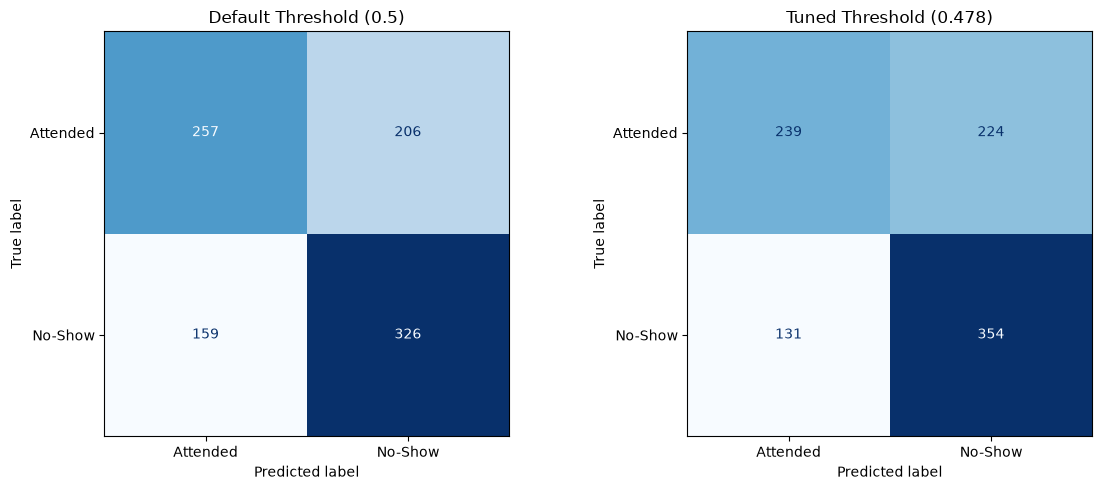

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_default), display_labels=['Attended','No-Show']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Default Threshold (0.5)')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_optimal), display_labels=['Attended','No-Show']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Tuned Threshold ({best_thresh:.3f})')
plt.tight_layout()
plt.show()

**Result:** The tuned threshold of 0.478 is better for this project because it identifies more actual no-shows. Recall increased from 0.672 to 0.730, meaning the model caught more missed appointments. Precision stayed almost the same, while accuracy and F1 score improved slightly.

**What this means:** This means the model produces more alerts, but it also misses fewer no-shows. That is useful because missed no-shows are more costly than sending some unnecessary reminders.

### Saving Processed Dataset

In [27]:
df_model.to_csv('HealthConnect_Cleaned_Modelling_Data_Week7.csv', index=False)
print("Saved: HealthConnect_Cleaned_Modelling_Data_Week7.csv")
print("Shape:", df_model.shape)

Saved: HealthConnect_Cleaned_Modelling_Data_Week7.csv
Shape: (4737, 22)


### Final Candidate Model Recommendation for Week 8

**Recommended model:** Logistic Regression, trained on the 11-feature refined set, with a **tuned classification threshold of ~0.478** (rather than the default 0.5).

**Why:**
- Cross-validated AUC is 0.679, with a small standard deviation of 0.011. It performs as well as the full feature set, so the result is reliable
- Logistic Regression has a small overfitting gap of 0.026, compared with 0.096 for Gradient Boosting. This shows that Logistic Regression performs better on new data.
- Threshold tuning delivers a genuine, evidence-based recall improvement (0.672 → 0.730) directly aligned with HealthConnect's stated priority of catching missed appointments

**Business relevance:** The model catches more true no-shows with almost no reduction in precision. This is a practical improvement for a tool that flags appointment risks.

**Suitability assessment:** The model should support staff decisions, not make decisions on its own. Human review is especially important for Specialist Consultations and the small “Prefer not to say” gender group, where performance is less certain.

### Assumptions, Limitations, Risks & Dependencies. Weeks 4 to 7

**Resolved this week:**

- Whether the Week 6 feature refinement was a single-split fluke: resolved through five-fold cross-validation, which confirmed its robustness (p = 0.9544).

- Whether Gradient Boosting was a viable alternative: resolved; its overfitting shows that it is not suitable for this dataset.

- Whether the default threshold was appropriate: resolved; the tuned threshold produced a measurable, evidence-based improvement in recall.

**Remaining issues:**

- Specialist Consultations underperform (AUC 0.588) compared with other appointment types. This was not resolved by this week’s refinement and requires attention in Week 8.

- The overall predictive ceiling of approximately 0.68 AUC remains. Feature engineering has not meaningfully improved performance over the past three weeks.


**New issue discovered:**

- The “Prefer not to say” gender group has very low apparent performance (AUC 0.453). However, with only 16 cases, the sample is too small to determine whether this reflects a genuine fairness issue or random variation. The group should be monitored rather than treated as either resolved or ignored.


**New cross-track dependency:**

- ML Engineering must implement the tuned threshold of 0.478, not just the model itself, during pipeline integration. This must be communicated clearly because using the default threshold would remove the recall improvement achieved this week.


**Testing limitation:**

- Segment analysis used a single test split of 947 cases. Segment-aware cross-validation would provide stronger evidence but was not conducted this week.

**Potential project impact:**

- If the Specialist Consultation weakness and the small gender segment are not addressed before wider rollout, HealthConnect may experience inconsistent risk-flagging quality across patient groups.


**Recommended mitigation:**

- Continue human review for both segments, regardless of the model’s output. Consider targeted data collection to increase the “Prefer not to say” sample before drawing firm conclusions.
